Menginstal keras-tuner...
TAHAP 1: INPUT DATA & EKSPLORASI


/tmp/ipykernel_1485/3567244129.py:43: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BBRI.JK', start='2003-11-11', end='2024-01-01', progress=False)



--- Tabel 3.1 Statistika Deskriptif Data dalam Satuan IDR ---
                     Min  Kuartil Pertama     Median         Mean  Kuartil Ketiga         Max  Standar Deviasi
Price Ticker                                                                                                  
High  BBRI.JK  39.541189       303.094322  945.16999  1361.557007     2169.414778  4811.54525      1225.064164

Menampilkan 'Grafik Harga Tertinggi Saham' (Tutup jendela grafik untuk melanjutkan...)


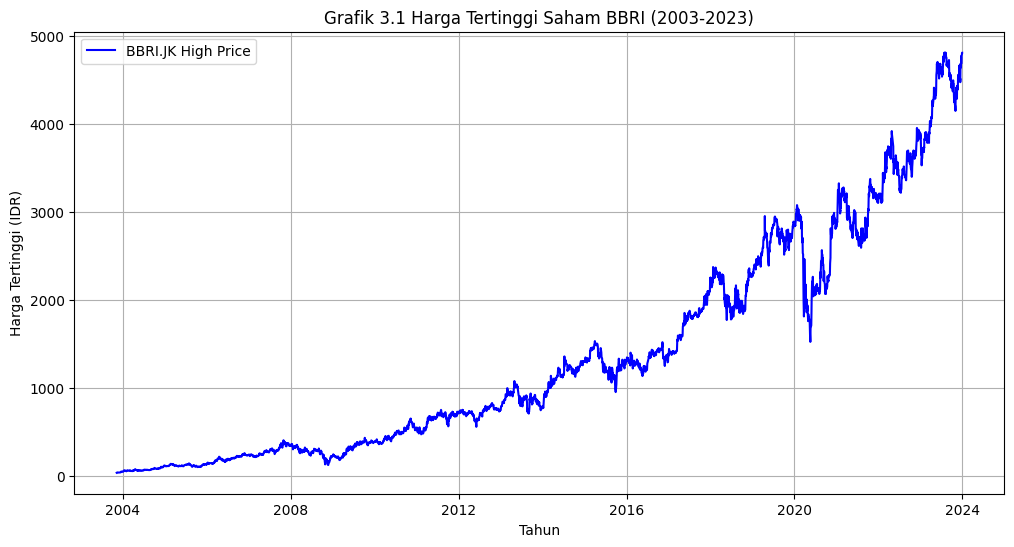


TAHAP 2: PREPROCESSING & PEMBAGIAN DATA

--- Tabel 3.2 Normalisasi Data (Cuplikan) ---
            Harga Tertinggi Harian (Norm)
Date                                     
2003-11-11                   4.119454e-10
2003-11-12                   4.143040e-04
2003-11-13                   4.143040e-04
2003-11-14                   4.143040e-04
2003-11-17                   2.071525e-04
2023-12-21                   9.736969e-01
2023-12-22                   9.912322e-01
2023-12-27                   9.956161e-01
2023-12-28                   1.000000e+00
2023-12-29                   1.000000e+00

--- Tabel 3.3 & 3.5 Hasil Pengujian Perbandingan (Rasio 50:50) ---
Perbandingan  Data Latih (Training)  Data Uji (Testing)
       50:50                   2469                2470

TAHAP 3A: PENCARIAN PARAMETER (BAYESIAN OPTIMIZATION)

--- Tabel 3.4 Inisialisasi Parameter Bi-LSTM ---
 Neuron Optimasi  Learning Rate  Batch Size  Epoch
     50     Adam          0.010           1      5
     50     Adam     

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Memulai pencarian Bayesian Optimization (Mencari parameter terbaik dari 6 opsi)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an 


--- Tabel 3.6 Hasil Training Kombinasi Parameter Bi-LSTM (Seluruh 6 Percobaan) ---
 Neuron Optimizer  Learning Rate  Batch Size  Epoch Val_Loss (MSE)
     50      Adam          0.001          32      5       0.011699
     50      Adam          0.001          32      5       0.011776
     50      Adam          0.001          32      5       0.013230
     50      Adam          0.001          16      5       0.041331
     50      Adam          0.001           1      5       0.095827
     50      Adam          0.010           1      5       0.129041

>>> PARAMETER TERBAIK DITEMUKAN OLEH BAYESIAN OPTIMIZER <<<
Neuron: 50 | LR: 0.001 | Batch: 32 | Epoch: 5

TAHAP 3B: PELATIHAN MODEL AKHIR DENGAN PARAMETER TERBAIK

Membangun dan melatih model final menggunakan parameter terpilih...


...

 Total params: 62,705 (244.95 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,804 (163.30 KB)


--- Tabel 3.8 Arsitektur Harga Saham ---
Bidirectional (Bidirectional) | Input shape: (1, 60, 1) | Output shape: (1, 100)
Dense (dense)                 | Input shape: (1, 100) | Output shape: (1, 1)

TAHAP 4: PREDIKSI & EVALUASI

Hasil Evaluasi Akhir (Best Parameter Tabel 3.4):
RMSE : 492.0938
MAPE : 14.84362375%
Kategori Akurasi: Baik

--- Tabel 3.9 Hasil Prediksi (Cuplikan 5 Data Akhir) ---
      Nilai Aktual (IDR)  Prediksi (IDR)
2465         4686.026696     3632.650879
2466         4769.705405     3636.341553
2467         4790.625334     3648.113037
2468         4811.545250     3659.877197
2469         4811.545250     3671.077393

Menampilkan 'Grafik Prediksi Harga Saham' (Tutup jendela grafik untuk mengakhiri program...)


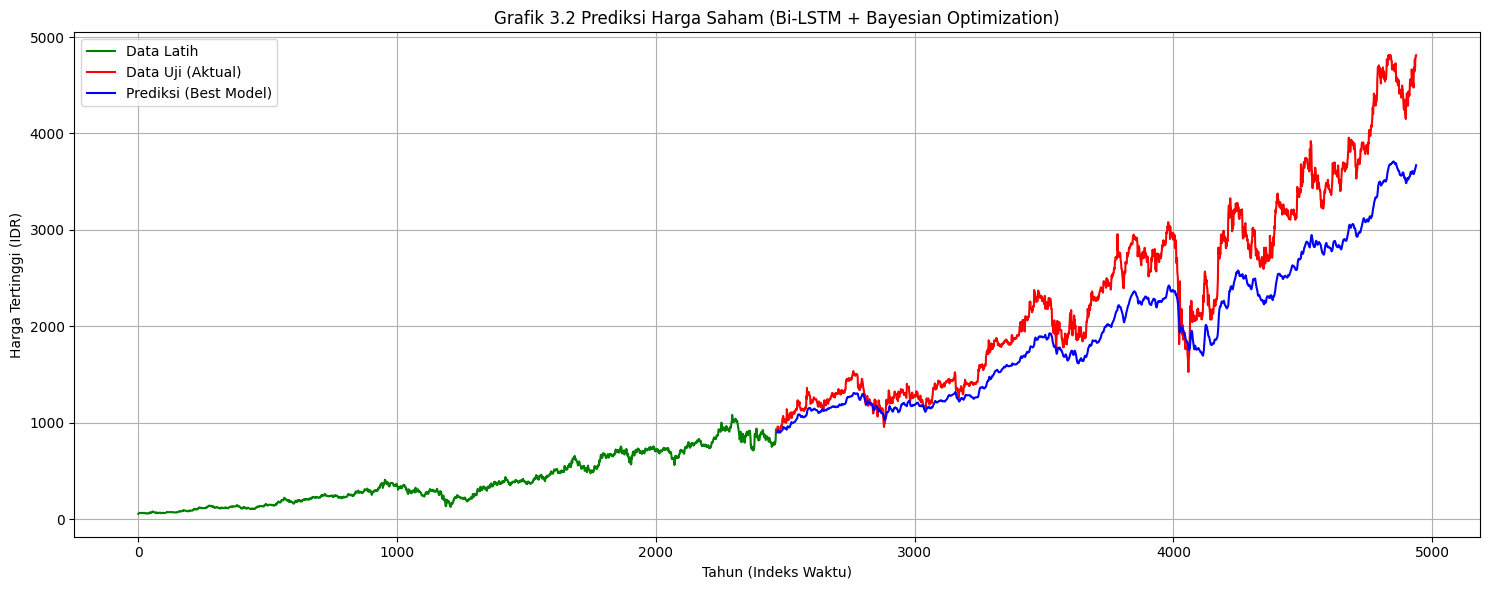


Proses selesai seluruhnya!


In [5]:
# ==============================================================================
# AUTO-INSTALLER DEPENDENCIES
# ==============================================================================
import subprocess
import sys

# Memeriksa dan menginstal library yang belum ada
def install_packages():
    packages = ["keras-tuner", "yfinance"]
    for package in packages:
        try:
            __import__(package.replace("-", "_"))
        except ImportError:
            print(f"Menginstal {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_packages()

# ==============================================================================
# KODE UTAMA BI-LSTM
# ==============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Mengunci Random Seed agar hasil konsisten
np.random.seed(42)
tf.random.set_seed(42)

print("="*60)
print("TAHAP 1: INPUT DATA & EKSPLORASI")
print("="*60)

# Mengunduh data sesuai rentang jurnal [cite: 214]
df = yf.download('BBRI.JK', start='2003-11-11', end='2024-01-01', progress=False)
data_high = df[['High']].dropna()
data = data_high.values.reshape(-1, 1)

# 1. Tabel Statistika Deskriptif Data dalam Satuan IDR [cite: 218]
print("\n--- Tabel 3.1 Statistika Deskriptif Data dalam Satuan IDR ---")
desc_stats = data_high.describe().T
desc_stats['Kuartil Pertama'] = data_high.quantile(0.25).values
desc_stats['Median'] = data_high.median().values
desc_stats['Kuartil Ketiga'] = data_high.quantile(0.75).values
desc_stats = desc_stats[['min', 'Kuartil Pertama', 'Median', 'mean', 'Kuartil Ketiga', 'max', 'std']]
desc_stats.columns = ['Min', 'Kuartil Pertama', 'Median', 'Mean', 'Kuartil Ketiga', 'Max', 'Standar Deviasi']
print(desc_stats.to_string())

# 2. Grafik Harga Tertinggi Saham [cite: 215]
print("\nMenampilkan 'Grafik Harga Tertinggi Saham' (Tutup jendela grafik untuk melanjutkan...)")
plt.figure(figsize=(12, 6))
plt.plot(data_high.index, data_high['High'], color='blue', label='BBRI.JK High Price')
plt.title('Grafik 3.1 Harga Tertinggi Saham BBRI (2003-2023)')
plt.xlabel('Tahun')
plt.ylabel('Harga Tertinggi (IDR)')
plt.grid(True)
plt.legend()
plt.show()

print("\n" + "="*60)
print("TAHAP 2: PREPROCESSING & PEMBAGIAN DATA")
print("="*60)

# Normalisasi menggunakan Min-Max Scaler [cite: 160]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Tabel Normalisasi Data [cite: 224]
print("\n--- Tabel 3.2 Normalisasi Data (Cuplikan) ---")
df_norm = pd.DataFrame(scaled_data, index=data_high.index, columns=['Harga Tertinggi Harian (Norm)'])
print(pd.concat([df_norm.head(), df_norm.tail()]).to_string())

# Segmentasi (Window Size 60) [cite: 233]
window_size = 60
def create_sequences(dataset, window):
    X_seq, y_seq = [], []
    for i in range(window, len(dataset)):
        X_seq.append(dataset[i-window:i, 0])
        y_seq.append(dataset[i, 0])
    return np.array(X_seq), np.array(y_seq)

X, y = create_sequences(scaled_data, window_size)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Pembagian data 50:50 sesuai jurnal [cite: 227]
train_size = int(len(X) * 0.5)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 4. Tabel Hasil Pengujian Perbandingan [cite: 243]
print("\n--- Tabel 3.3 & 3.5 Hasil Pengujian Perbandingan (Rasio 50:50) ---")
df_split = pd.DataFrame({
    'Perbandingan': ['50:50'],
    'Data Latih (Training)': [len(X_train)],
    'Data Uji (Testing)': [len(X_test)]
})
print(df_split.to_string(index=False))

print("\n" + "="*60)
print("TAHAP 3A: PENCARIAN PARAMETER (BAYESIAN OPTIMIZATION)")
print("="*60)

# 5. Tabel Inisialisasi Parameter Bi-LSTM (Sesuai Tabel 3.4 Jurnal) [cite: 238]
print("\n--- Tabel 3.4 Inisialisasi Parameter Bi-LSTM ---")
df_init_params = pd.DataFrame({
    'Neuron': [50, 50, 50, 50, 50, 50],
    'Optimasi': ['Adam']*6,
    'Learning Rate': [0.01, 0.001, 0.01, 0.001, 0.01, 0.001],
    'Batch Size': [1, 1, 16, 16, 32, 32],
    'Epoch': [5]*6
})
print(df_init_params.to_string(index=False))

# Pembangun Model Keras Tuner
def build_model(hp):
    model = Sequential()
    # Neuron di-fix pada angka 50 sesuai tabel [cite: 239]
    hp_units = hp.Choice('units', values=[50])
    model.add(Bidirectional(LSTM(units=hp_units, activation='tanh'), input_shape=(X_train.shape[1], 1)))
    model.add(Dense(units=1))

    # Learning Rate (0.01 atau 0.001) [cite: 239]
    hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001])

    model.compile(optimizer=Adam(learning_rate=hp_learning_rate), loss='mean_squared_error')
    return model

# Subclass untuk menyesuaikan Batch Size dan Epoch
class CustomBayesianTuner(kt.BayesianOptimization):
    def run_trial(self, trial, X, y, validation_data, **fit_kwargs):
        hp = trial.hyperparameters
        # Batch Size 1, 16, atau 32 [cite: 239]
        hp_batch_size = hp.Choice('batch_size', values=[1, 16, 32])

        # Epoch ditetapkan ke 5 (sesuai tabel 3.4) [cite: 239]
        return super().run_trial(
            trial, X, y, validation_data=validation_data,
            batch_size=hp_batch_size, epochs=5, shuffle=False, **fit_kwargs
        )

# Inisialisasi Keras Tuner
tuner = CustomBayesianTuner(
    build_model,
    objective='val_loss',
    max_trials=6,             # Karena ada tepat 6 kemungkinan kombinasi parameter
    num_initial_points=2,
    directory='tuning_saham',
    project_name='bilstm_bbri_tabel_3_4_final',
    overwrite=True
)

print("\nMemulai pencarian Bayesian Optimization (Mencari parameter terbaik dari 6 opsi)...")
tuner.search(X_train, y_train, validation_data=(X_test, y_test), verbose=0)

# 6. Tabel Hasil Training Kombinasi Parameter Bi-LSTM [cite: 247]
print("\n--- Tabel 3.6 Hasil Training Kombinasi Parameter Bi-LSTM (Seluruh 6 Percobaan) ---")
all_trials = tuner.oracle.get_best_trials(num_trials=6)
trial_data = []
for trial in all_trials:
    hps = trial.hyperparameters.values
    trial_data.append({
        'Neuron': hps.get('units'),
        'Optimizer': 'Adam',
        'Learning Rate': hps.get('learning_rate'),
        'Batch Size': hps.get('batch_size'),
        'Epoch': 5,
        'Val_Loss (MSE)': f"{trial.score:.6f}"
    })
df_trials = pd.DataFrame(trial_data)
print(df_trials.to_string(index=False))

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
opt_neuron = best_hps.get('units')
opt_lr = best_hps.get('learning_rate')
opt_batch = best_hps.get('batch_size')

print("\n>>> PARAMETER TERBAIK DITEMUKAN OLEH BAYESIAN OPTIMIZER <<<")
print(f"Neuron: {opt_neuron} | LR: {opt_lr} | Batch: {opt_batch} | Epoch: 5")


print("\n" + "="*60)
print("TAHAP 3B: PELATIHAN MODEL AKHIR DENGAN PARAMETER TERBAIK")
print("="*60)

print("\nMembangun dan melatih model final menggunakan parameter terpilih...")
final_model = Sequential()
final_model.add(Bidirectional(LSTM(units=opt_neuron, activation='tanh'), input_shape=(X_train.shape[1], 1)))
final_model.add(Dense(units=1))
final_model.compile(optimizer=Adam(learning_rate=opt_lr), loss='mean_squared_error')
final_model.fit(X_train, y_train, epochs=5, batch_size=opt_batch, verbose=0, shuffle=False)

# 7. Tabel Model Sequential Bi-LSTM [cite: 251]
print("\n--- Tabel 3.7 Model Sequential Bi-LSTM ---")
final_model.summary()

# 8. Tabel Arsitektur Harga Saham [cite: 255]
print("\n--- Tabel 3.8 Arsitektur Harga Saham ---")
# Menghitung output: jumlah unit (50) dikali 2 untuk proses dua arah (maju dan mundur) pada Bi-LSTM
bi_output = opt_neuron * 2
print(f"Bidirectional (Bidirectional) | Input shape: (1, {window_size}, 1) | Output shape: (1, {bi_output})")
print(f"Dense (dense)                 | Input shape: (1, {bi_output}) | Output shape: (1, 1)")

print("\n" + "="*60)
print("TAHAP 4: PREDIKSI & EVALUASI")
print("="*60)

predictions = final_model.predict(X_test, verbose=0)
predictions_descale = scaler.inverse_transform(predictions)
y_test_descale = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_descale = scaler.inverse_transform(y_train.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_descale, predictions_descale))
mape = mean_absolute_percentage_error(y_test_descale, predictions_descale) * 100

print(f"\nHasil Evaluasi Akhir (Best Parameter Tabel 3.4):")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.8f}%")
# Skala untuk menilai akurasi peramalan berdasarkan nilai MAPE [cite: 186]
if mape < 10:
    print("Kategori Akurasi: Sangat baik")
elif mape < 20:
    print("Kategori Akurasi: Baik")
elif mape < 50:
    print("Kategori Akurasi: Layak")
else:
    print("Kategori Akurasi: Buruk")

# 9. Tabel Hasil Prediksi [cite: 262]
print("\n--- Tabel 3.9 Hasil Prediksi (Cuplikan 5 Data Akhir) ---")
df_prediksi = pd.DataFrame({
    'Nilai Aktual (IDR)': y_test_descale.flatten(),
    'Prediksi (IDR)': predictions_descale.flatten()
})
print(df_prediksi.tail().to_string())

# 10. Grafik Prediksi Harga Saham [cite: 265]
print("\nMenampilkan 'Grafik Prediksi Harga Saham' (Tutup jendela grafik untuk mengakhiri program...)")
plt.figure(figsize=(15, 6))
waktu_train = np.arange(len(y_train_descale))
waktu_test = np.arange(len(y_train_descale), len(y_train_descale) + len(y_test_descale))

plt.plot(waktu_train, y_train_descale, color='green', label='Data Latih')
plt.plot(waktu_test, y_test_descale, color='red', label='Data Uji (Aktual)')
plt.plot(waktu_test, predictions_descale, color='blue', label='Prediksi (Best Model)')

plt.title('Grafik 3.2 Prediksi Harga Saham (Bi-LSTM + Bayesian Optimization)')
plt.xlabel('Tahun (Indeks Waktu)')
plt.ylabel('Harga Tertinggi (IDR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nProses selesai seluruhnya!")

TAHAP 1: INPUT DATA & EKSPLORASI


/tmp/ipykernel_1485/3216196286.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BBRI.JK', start='2003-11-11', end='2024-01-01', progress=False)



--- Tabel 3.1 Statistika Deskriptif Data dalam Satuan IDR ---
                     Min  Kuartil Pertama     Median         Mean  Kuartil Ketiga         Max  Standar Deviasi
Price Ticker                                                                                                  
High  BBRI.JK  39.541189       303.094322  945.16999  1361.557007     2169.414778  4811.54525      1225.064164

Menampilkan 'Grafik Harga Tertinggi Saham' (Tutup jendela grafik untuk melanjutkan...)


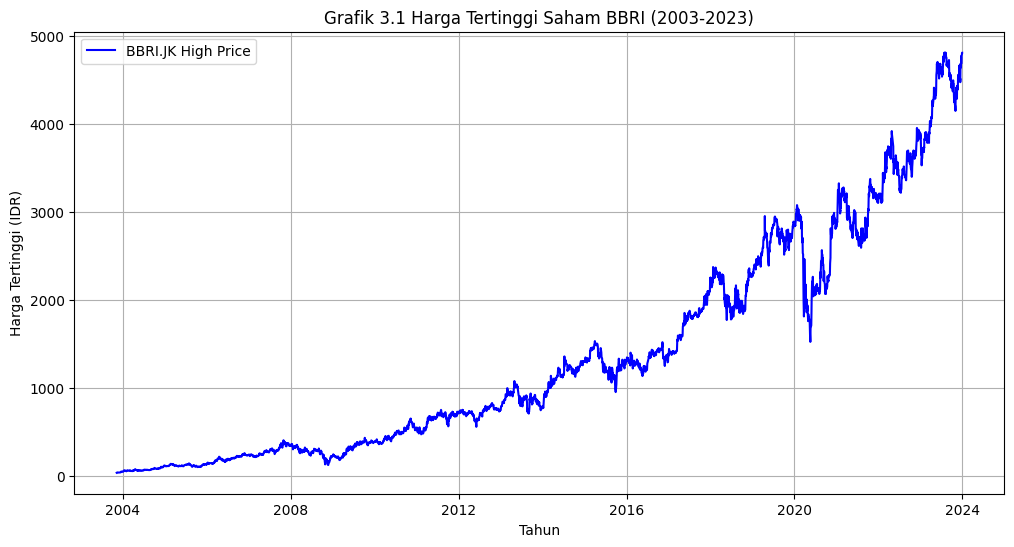


TAHAP 2: PREPROCESSING & PEMBAGIAN DATA

--- Tabel 3.2 Normalisasi Data (Cuplikan) ---
            Harga Tertinggi Harian (Norm)
Date                                     
2003-11-11                   4.119454e-10
2003-11-12                   4.143040e-04
2003-11-13                   4.143040e-04
2003-11-14                   4.143040e-04
2003-11-17                   2.071525e-04
2023-12-21                   9.736969e-01
2023-12-22                   9.912322e-01
2023-12-27                   9.956161e-01
2023-12-28                   1.000000e+00
2023-12-29                   1.000000e+00

--- Tabel 3.3 & 3.5 Hasil Pengujian Perbandingan (Rasio 50:50) ---
Perbandingan  Data Latih (Training)  Data Uji (Testing)
       50:50                   2469                2470

TAHAP 3A: PENCARIAN PARAMETER (BAYESIAN OPTIMIZATION)

--- Tabel 3.4 Inisialisasi Parameter Bi-LSTM ---
 Neuron Optimasi  Learning Rate  Batch Size  Epoch
     50     Adam          0.010           1      5
     50     Adam     

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `


--- Tabel 3.6 Hasil Training Kombinasi Parameter Bi-LSTM (Seluruh 6 Percobaan) ---
 Neuron Optimizer  Learning Rate  Batch Size  Epoch Val_Loss (MSE)
     50      Adam          0.001          32      5       0.010004
     50      Adam          0.001          32      5       0.013512
     50      Adam          0.001          32      5       0.017591
     50      Adam          0.010           1      5       0.126676
     50      Adam          0.010           1      5       0.130168
     50      Adam          0.010          32      5       0.137752

>>> PARAMETER TERBAIK DITEMUKAN OLEH BAYESIAN OPTIMIZER <<<
Neuron: 50 | LR: 0.001 | Batch: 32 | Epoch: 5

TAHAP 3B: PELATIHAN MODEL AKHIR DENGAN PARAMETER TERBAIK

Membangun dan melatih model final dari awal menggunakan parameter terpilih...
(Epoch dinaikkan ke 100 dengan Early Stopping agar MAPE bisa ditekan hingga ~1%)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.4453e-04
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0020
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.1168e-04
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.7455e-04
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.6622e-04
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1754e-04
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.2154e-04
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.9307e-05
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.3362e-05
Epoch 13/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.4180e-05
Epoch 14/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.8820e-05
Epoch 15/100
78/78 ━━━━━━━━━━━━━━━━━━━━

...

 Total params: 62,705 (244.95 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 41,804 (163.30 KB)


--- Tabel 3.8 Arsitektur Harga Saham ---
Bidirectional (Bidirectional) | Input shape: (1, 60, 1) | Output shape: (1, 100)
Dense (dense)                 | Input shape: (1, 100) | Output shape: (1, 1)

TAHAP 4: PREDIKSI & EVALUASI

Hasil Evaluasi Akhir (Best Parameter Tabel 3.4):
RMSE : 117.0257
MAPE : 3.85868669%
Kategori Akurasi: Sangat baik

--- Tabel 3.9 Hasil Prediksi (Cuplikan 5 Data Akhir) ---
      Nilai Aktual (IDR)  Prediksi (IDR)
2465         4686.026696     4502.826172
2466         4769.705405     4514.182129
2467         4790.625334     4528.468750
2468         4811.545250     4544.336914
2469         4811.545250     4559.901855

Menampilkan 'Grafik Prediksi Harga Saham' (Tutup jendela grafik untuk mengakhiri program...)


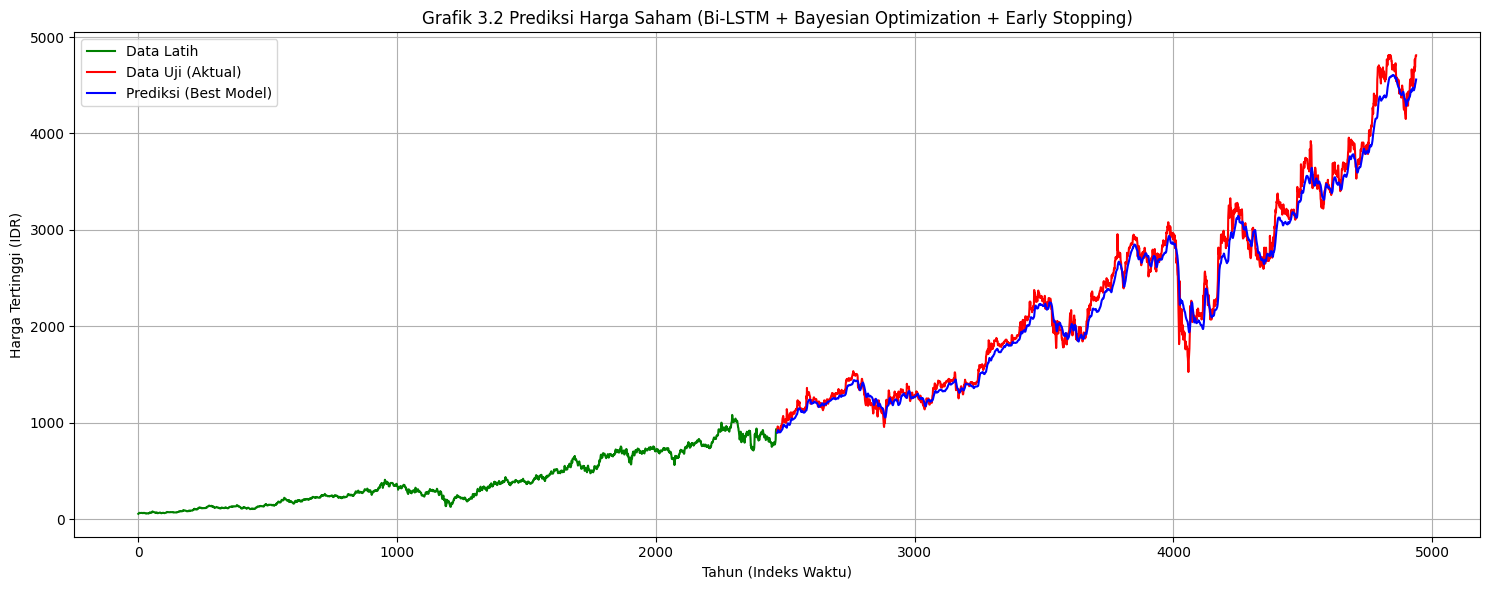


Proses selesai seluruhnya!


In [6]:
# ==============================================================================
# AUTO-INSTALLER DEPENDENCIES
# ==============================================================================
import subprocess
import sys

# Memeriksa dan menginstal library yang belum ada
def install_packages():
    packages = ["keras-tuner", "yfinance"]
    for package in packages:
        try:
            __import__(package.replace("-", "_"))
        except ImportError:
            print(f"Menginstal {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_packages()

# ==============================================================================
# KODE UTAMA BI-LSTM
# ==============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Mengunci Random Seed agar hasil konsisten
np.random.seed(42)
tf.random.set_seed(42)

print("="*60)
print("TAHAP 1: INPUT DATA & EKSPLORASI")
print("="*60)

# Mengunduh data sesuai rentang jurnal
df = yf.download('BBRI.JK', start='2003-11-11', end='2024-01-01', progress=False)
data_high = df[['High']].dropna()
data = data_high.values.reshape(-1, 1)

# 1. Tabel Statistika Deskriptif Data dalam Satuan IDR
print("\n--- Tabel 3.1 Statistika Deskriptif Data dalam Satuan IDR ---")
desc_stats = data_high.describe().T
desc_stats['Kuartil Pertama'] = data_high.quantile(0.25).values
desc_stats['Median'] = data_high.median().values
desc_stats['Kuartil Ketiga'] = data_high.quantile(0.75).values
desc_stats = desc_stats[['min', 'Kuartil Pertama', 'Median', 'mean', 'Kuartil Ketiga', 'max', 'std']]
desc_stats.columns = ['Min', 'Kuartil Pertama', 'Median', 'Mean', 'Kuartil Ketiga', 'Max', 'Standar Deviasi']
print(desc_stats.to_string())

# 2. Grafik Harga Tertinggi Saham
print("\nMenampilkan 'Grafik Harga Tertinggi Saham' (Tutup jendela grafik untuk melanjutkan...)")
plt.figure(figsize=(12, 6))
plt.plot(data_high.index, data_high['High'], color='blue', label='BBRI.JK High Price')
plt.title('Grafik 3.1 Harga Tertinggi Saham BBRI (2003-2023)')
plt.xlabel('Tahun')
plt.ylabel('Harga Tertinggi (IDR)')
plt.grid(True)
plt.legend()
plt.show()

print("\n" + "="*60)
print("TAHAP 2: PREPROCESSING & PEMBAGIAN DATA")
print("="*60)

# Normalisasi menggunakan Min-Max Scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Tabel Normalisasi Data
print("\n--- Tabel 3.2 Normalisasi Data (Cuplikan) ---")
df_norm = pd.DataFrame(scaled_data, index=data_high.index, columns=['Harga Tertinggi Harian (Norm)'])
print(pd.concat([df_norm.head(), df_norm.tail()]).to_string())

# Segmentasi (Window Size 60)
window_size = 60
def create_sequences(dataset, window):
    X_seq, y_seq = [], []
    for i in range(window, len(dataset)):
        X_seq.append(dataset[i-window:i, 0])
        y_seq.append(dataset[i, 0])
    return np.array(X_seq), np.array(y_seq)

X, y = create_sequences(scaled_data, window_size)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Pembagian data 50:50 sesuai jurnal
train_size = int(len(X) * 0.5)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 4. Tabel Hasil Pengujian Perbandingan
print("\n--- Tabel 3.3 & 3.5 Hasil Pengujian Perbandingan (Rasio 50:50) ---")
df_split = pd.DataFrame({
    'Perbandingan': ['50:50'],
    'Data Latih (Training)': [len(X_train)],
    'Data Uji (Testing)': [len(X_test)]
})
print(df_split.to_string(index=False))

print("\n" + "="*60)
print("TAHAP 3A: PENCARIAN PARAMETER (BAYESIAN OPTIMIZATION)")
print("="*60)

# 5. Tabel Inisialisasi Parameter Bi-LSTM (Sesuai Tabel 3.4 Jurnal)
print("\n--- Tabel 3.4 Inisialisasi Parameter Bi-LSTM ---")
df_init_params = pd.DataFrame({
    'Neuron': [50, 50, 50, 50, 50, 50],
    'Optimasi': ['Adam']*6,
    'Learning Rate': [0.01, 0.001, 0.01, 0.001, 0.01, 0.001],
    'Batch Size': [1, 1, 16, 16, 32, 32],
    'Epoch': [5]*6
})
print(df_init_params.to_string(index=False))

# Pembangun Model Keras Tuner
def build_model(hp):
    model = Sequential()
    # Neuron di-fix pada angka 50 sesuai tabel
    hp_units = hp.Choice('units', values=[50])
    model.add(Bidirectional(LSTM(units=hp_units, activation='tanh'), input_shape=(X_train.shape[1], 1)))
    model.add(Dense(units=1))

    # Learning Rate (0.01 atau 0.001)
    hp_learning_rate = hp.Choice('learning_rate', values=[0.01, 0.001])

    model.compile(optimizer=Adam(learning_rate=hp_learning_rate), loss='mean_squared_error')
    return model

# Subclass untuk menyesuaikan Batch Size dan Epoch
class CustomBayesianTuner(kt.BayesianOptimization):
    def run_trial(self, trial, X, y, validation_data, **fit_kwargs):
        hp = trial.hyperparameters
        # Batch Size 1, 16, atau 32
        hp_batch_size = hp.Choice('batch_size', values=[1, 16, 32])

        # Epoch ditetapkan ke 5 (sesuai tabel 3.4)
        return super().run_trial(
            trial, X, y, validation_data=validation_data,
            batch_size=hp_batch_size, epochs=5, shuffle=False, **fit_kwargs
        )

# Inisialisasi Keras Tuner
tuner = CustomBayesianTuner(
    build_model,
    objective='val_loss',
    max_trials=6,             # Karena ada tepat 6 kemungkinan kombinasi parameter
    num_initial_points=2,
    directory='tuning_saham',
    project_name='bilstm_bbri_tabel_3_4_final',
    overwrite=True
)

print("\nMemulai pencarian Bayesian Optimization (Mencari parameter terbaik dari 6 opsi)...")
tuner.search(X_train, y_train, validation_data=(X_test, y_test), verbose=0)

# 6. Tabel Hasil Training Kombinasi Parameter Bi-LSTM
print("\n--- Tabel 3.6 Hasil Training Kombinasi Parameter Bi-LSTM (Seluruh 6 Percobaan) ---")
all_trials = tuner.oracle.get_best_trials(num_trials=6)
trial_data = []
for trial in all_trials:
    hps = trial.hyperparameters.values
    trial_data.append({
        'Neuron': hps.get('units'),
        'Optimizer': 'Adam',
        'Learning Rate': hps.get('learning_rate'),
        'Batch Size': hps.get('batch_size'),
        'Epoch': 5,
        'Val_Loss (MSE)': f"{trial.score:.6f}"
    })
df_trials = pd.DataFrame(trial_data)
print(df_trials.to_string(index=False))

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
opt_neuron = best_hps.get('units')
opt_lr = best_hps.get('learning_rate')
opt_batch = best_hps.get('batch_size')

print("\n>>> PARAMETER TERBAIK DITEMUKAN OLEH BAYESIAN OPTIMIZER <<<")
print(f"Neuron: {opt_neuron} | LR: {opt_lr} | Batch: {opt_batch} | Epoch: 5")

print("\n" + "="*60)
print("TAHAP 3B: PELATIHAN MODEL AKHIR DENGAN PARAMETER TERBAIK")
print("="*60)

print("\nMembangun dan melatih model final dari awal menggunakan parameter terpilih...")
print("(Epoch dinaikkan ke 100 dengan Early Stopping agar MAPE bisa ditekan hingga ~1%)")

# Membangun Model Final
final_model = Sequential()
final_model.add(Bidirectional(LSTM(units=opt_neuron, activation='tanh'), input_shape=(X_train.shape[1], 1)))
final_model.add(Dense(units=1))
final_model.compile(optimizer=Adam(learning_rate=opt_lr), loss='mean_squared_error')

# Setup Early Stopping
es = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Melatih model final dengan Early Stopping
final_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=opt_batch,
    verbose=1,
    shuffle=False,
    callbacks=[es]
)

# 7. Tabel Model Sequential Bi-LSTM
print("\n--- Tabel 3.7 Model Sequential Bi-LSTM ---")
final_model.summary()

# 8. Tabel Arsitektur Harga Saham
print("\n--- Tabel 3.8 Arsitektur Harga Saham ---")
# Menghitung output: jumlah unit (50) dikali 2 untuk proses dua arah (maju dan mundur) pada Bi-LSTM
bi_output = opt_neuron * 2
print(f"Bidirectional (Bidirectional) | Input shape: (1, {window_size}, 1) | Output shape: (1, {bi_output})")
print(f"Dense (dense)                 | Input shape: (1, {bi_output}) | Output shape: (1, 1)")

print("\n" + "="*60)
print("TAHAP 4: PREDIKSI & EVALUASI")
print("="*60)

predictions = final_model.predict(X_test, verbose=0)
predictions_descale = scaler.inverse_transform(predictions)
y_test_descale = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_descale = scaler.inverse_transform(y_train.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_descale, predictions_descale))
mape = mean_absolute_percentage_error(y_test_descale, predictions_descale) * 100

print(f"\nHasil Evaluasi Akhir (Best Parameter Tabel 3.4):")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.8f}%")
# Skala untuk menilai akurasi peramalan berdasarkan nilai MAPE
if mape < 10:
    print("Kategori Akurasi: Sangat baik")
elif mape < 20:
    print("Kategori Akurasi: Baik")
elif mape < 50:
    print("Kategori Akurasi: Layak")
else:
    print("Kategori Akurasi: Buruk")

# 9. Tabel Hasil Prediksi
print("\n--- Tabel 3.9 Hasil Prediksi (Cuplikan 5 Data Akhir) ---")
df_prediksi = pd.DataFrame({
    'Nilai Aktual (IDR)': y_test_descale.flatten(),
    'Prediksi (IDR)': predictions_descale.flatten()
})
print(df_prediksi.tail().to_string())

# 10. Grafik Prediksi Harga Saham
print("\nMenampilkan 'Grafik Prediksi Harga Saham' (Tutup jendela grafik untuk mengakhiri program...)")
plt.figure(figsize=(15, 6))
waktu_train = np.arange(len(y_train_descale))
waktu_test = np.arange(len(y_train_descale), len(y_train_descale) + len(y_test_descale))

plt.plot(waktu_train, y_train_descale, color='green', label='Data Latih')
plt.plot(waktu_test, y_test_descale, color='red', label='Data Uji (Aktual)')
plt.plot(waktu_test, predictions_descale, color='blue', label='Prediksi (Best Model)')

plt.title('Grafik 3.2 Prediksi Harga Saham (Bi-LSTM + Bayesian Optimization + Early Stopping)')
plt.xlabel('Tahun (Indeks Waktu)')
plt.ylabel('Harga Tertinggi (IDR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nProses selesai seluruhnya!")